## Importing Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

## Loading Titanic Survival Dataset from Seasborn 

In [25]:
df = sns.load_dataset("titanic")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## EDA

In [26]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [28]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(107)

In [31]:
df['age'].skew()

np.float64(0.38910778230082704)

<Axes: xlabel='age', ylabel='Count'>

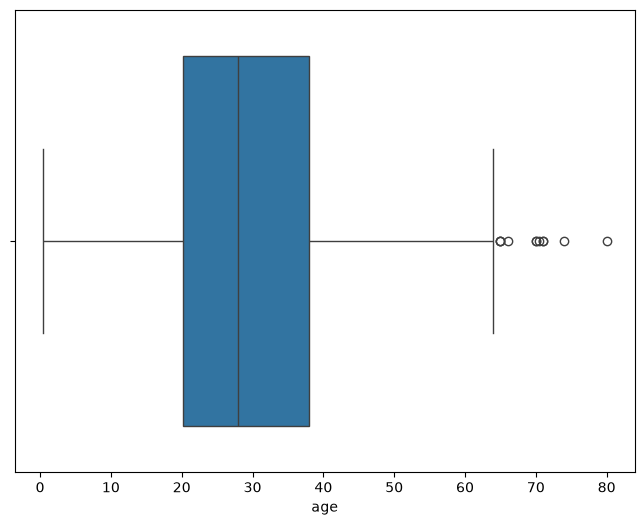

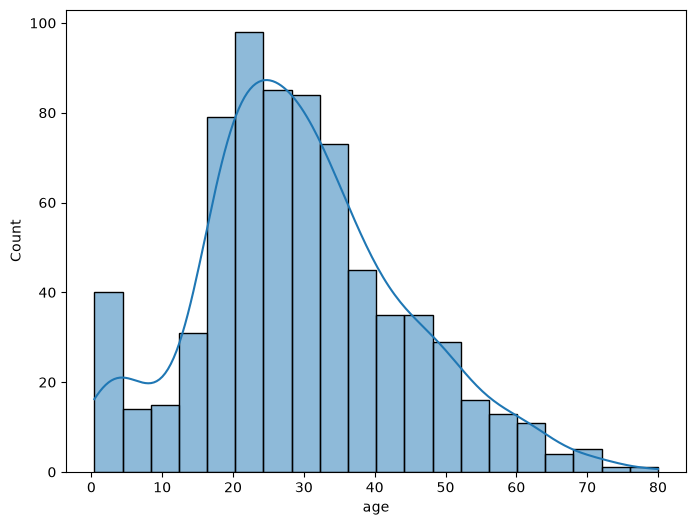

In [32]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x= 'age')

plt.figure(figsize=(8,6))
sns.histplot(data=df, x= 'age', kde=True)

In [33]:
df['age'].value_counts()

age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [34]:
numerical_columns = df.select_dtypes(include=[int,float]) 
numerical_columns

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


## Plotting Boxplot to spot outliers

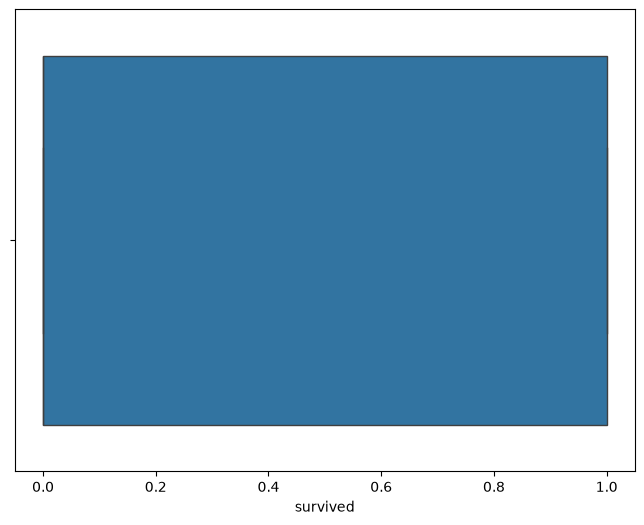

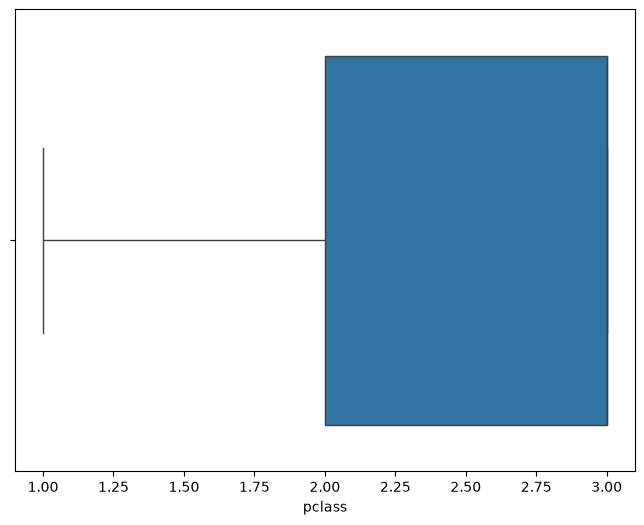

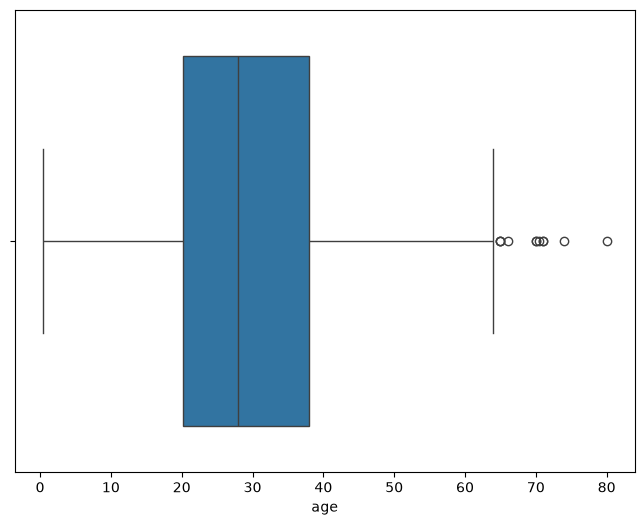

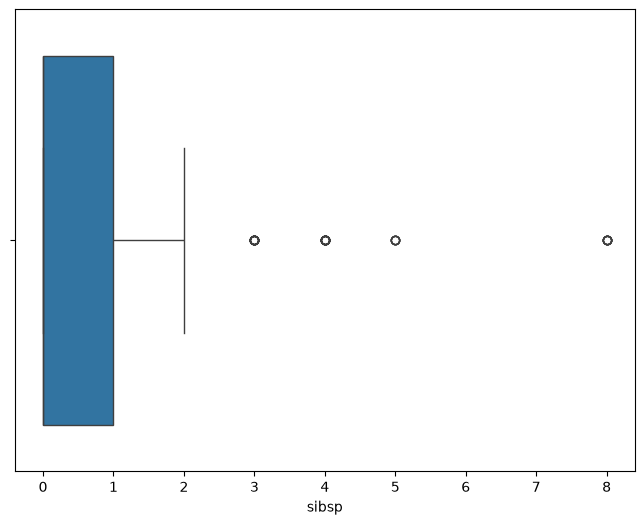

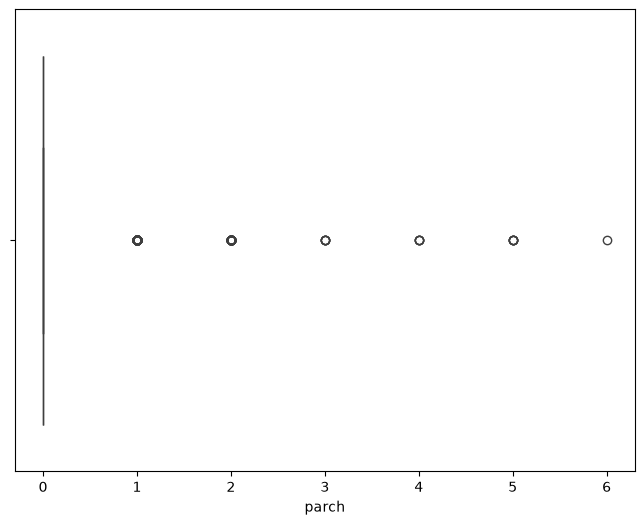

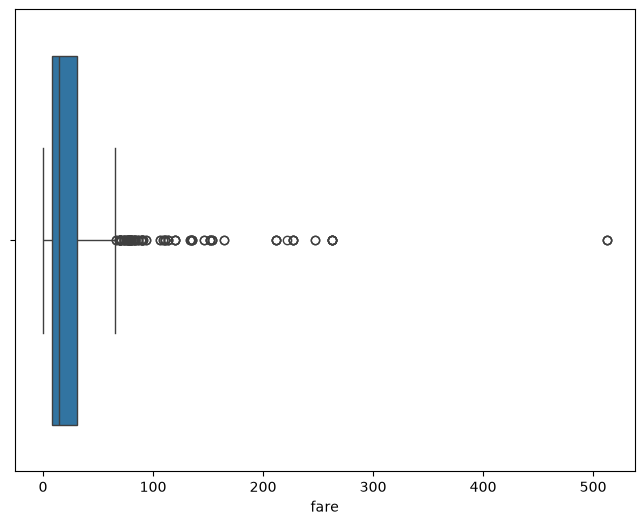

In [35]:
for col in numerical_columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=df , x=col)
    plt.show()

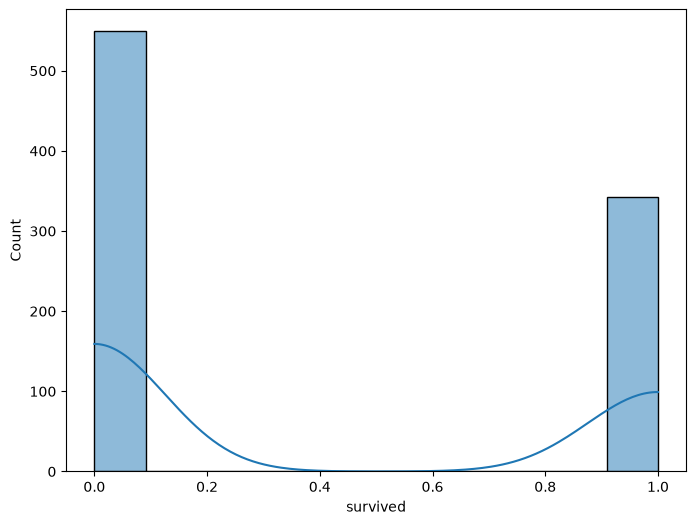

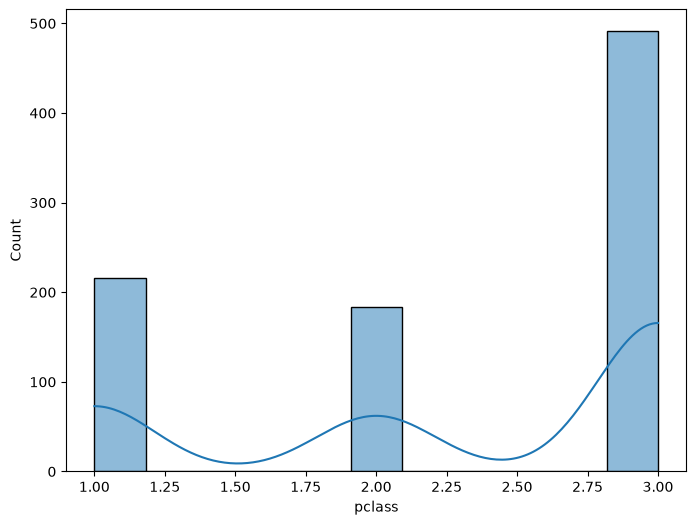

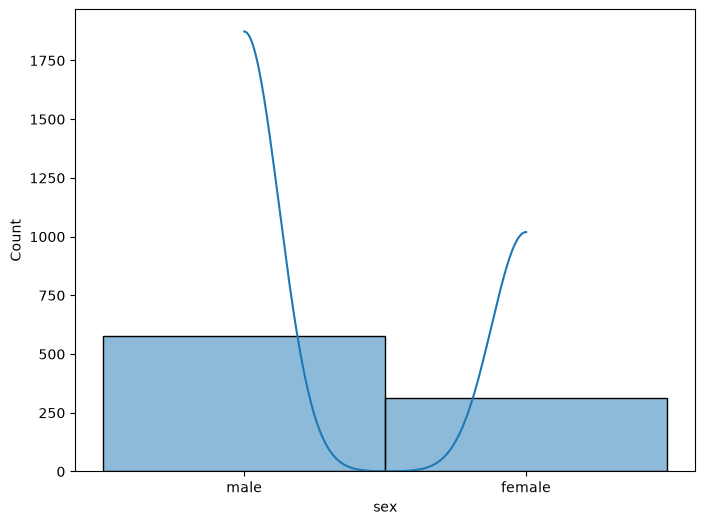

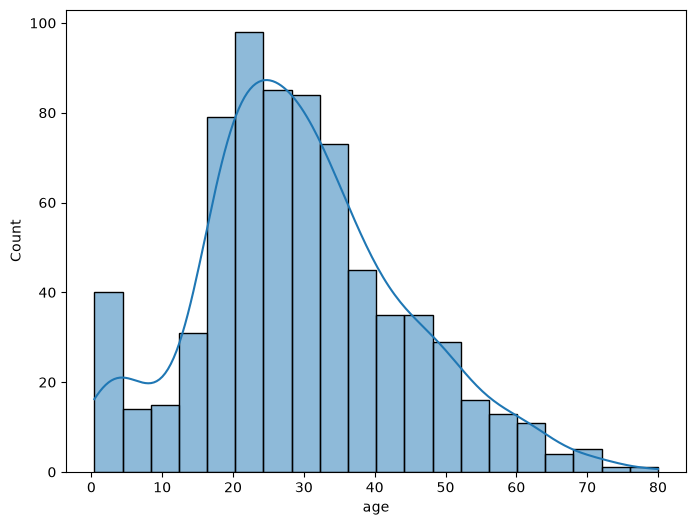

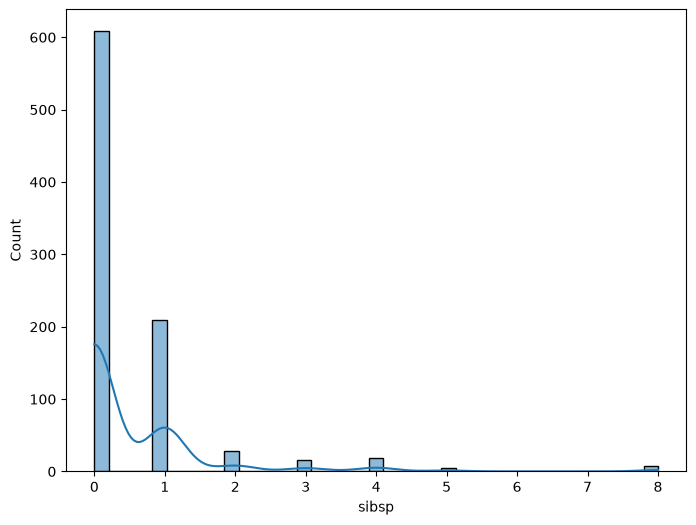

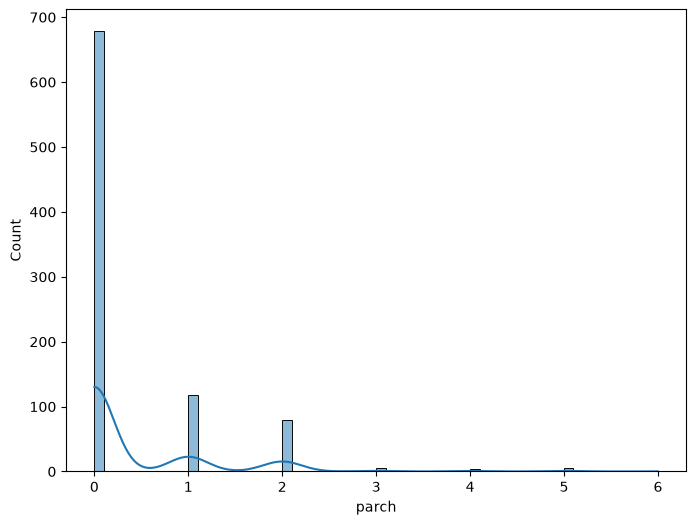

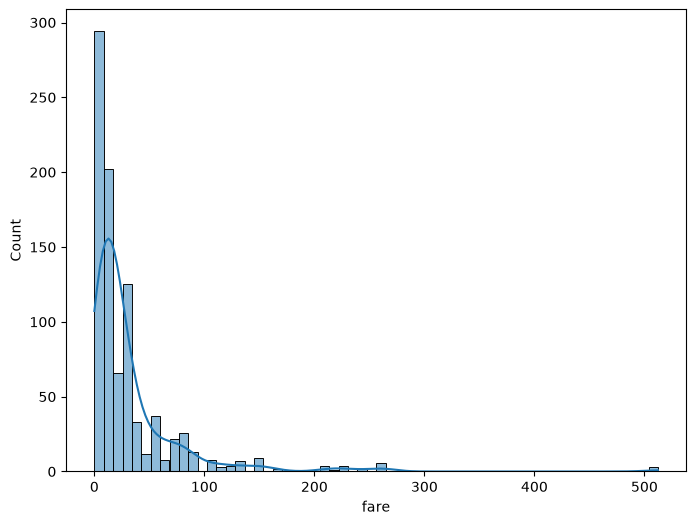

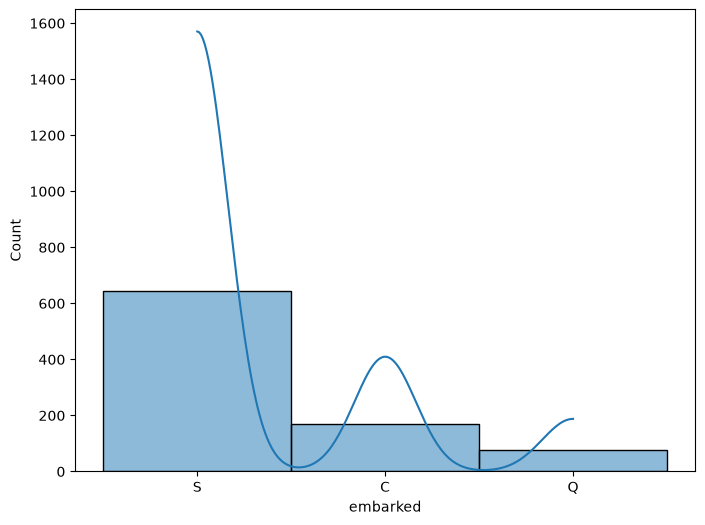

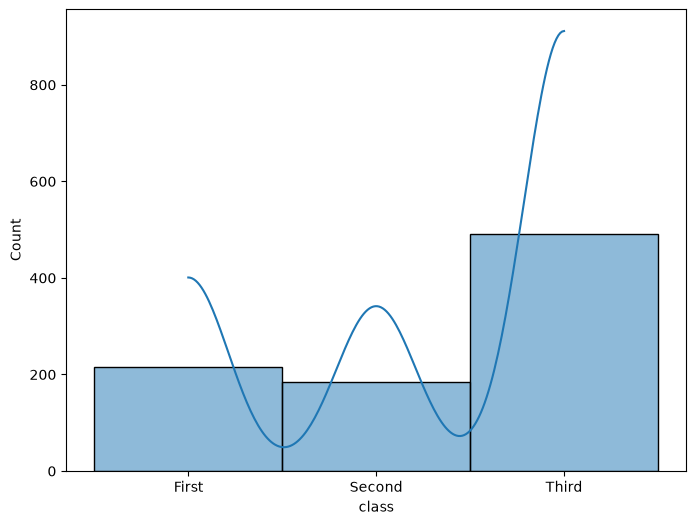

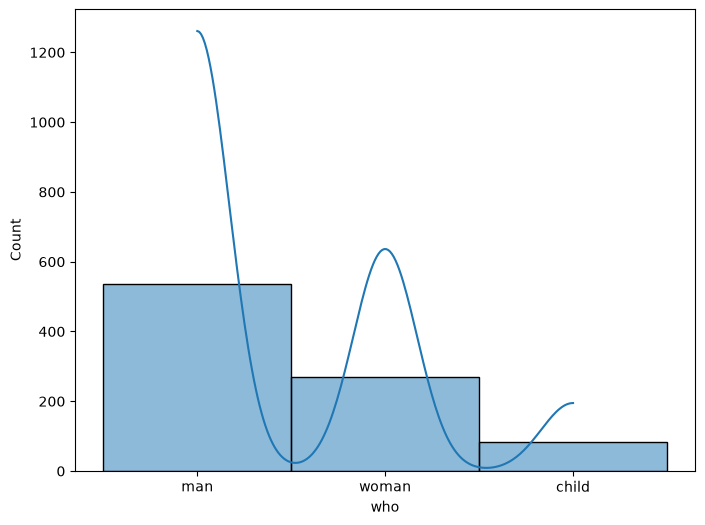

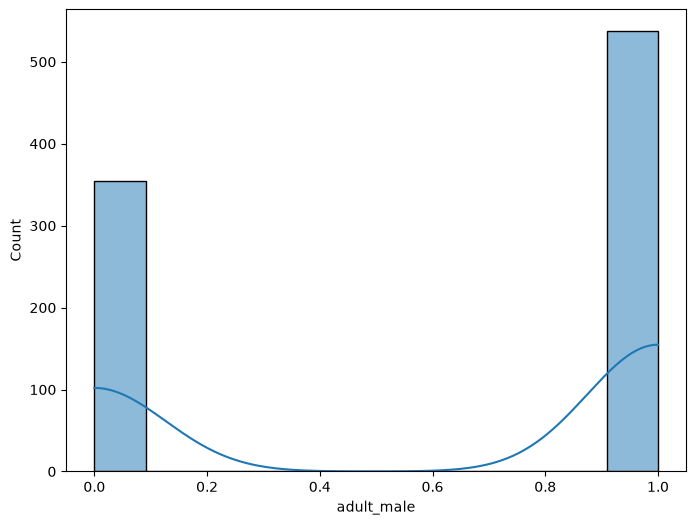

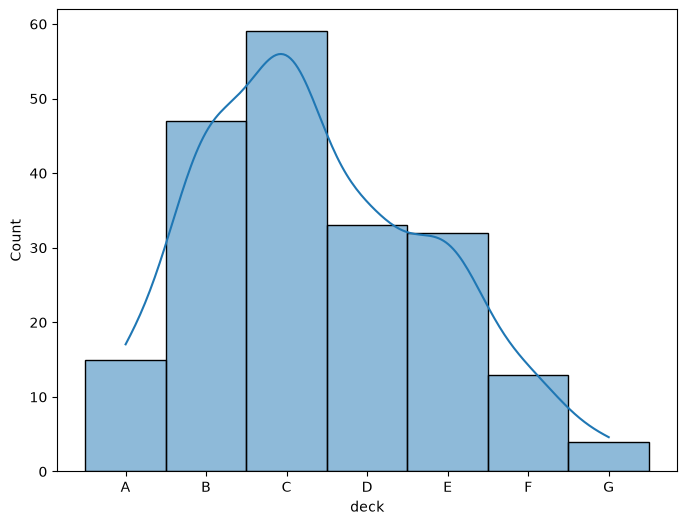

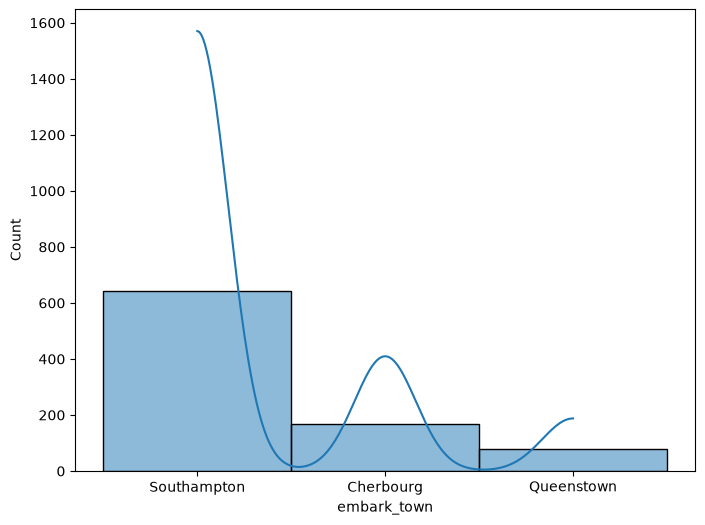

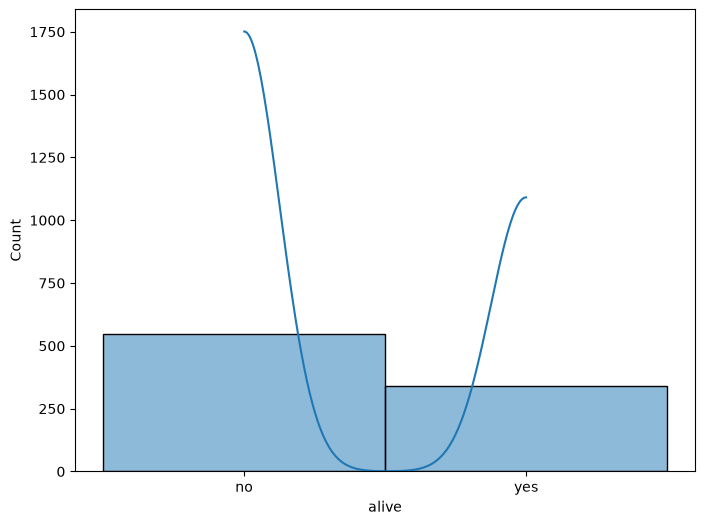

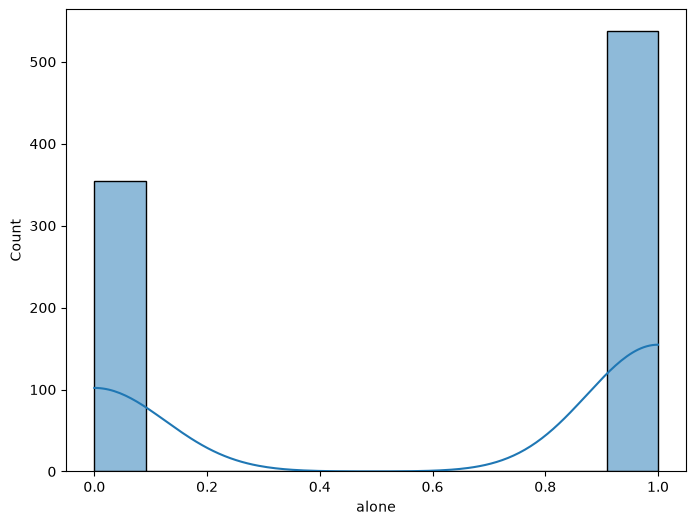

In [36]:
for col in df:
    plt.figure(figsize=(8,6))
    sns.histplot(data=df , x=col, kde=True)
    plt.show()

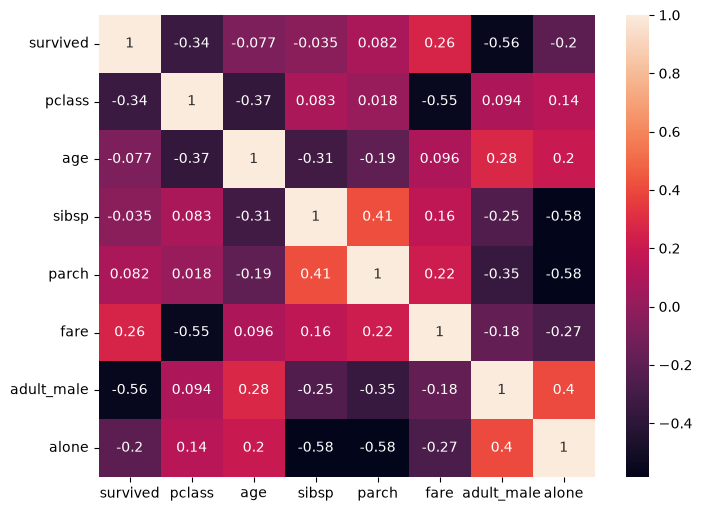

In [37]:
# Plotting Heatmap to check correlation

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: xlabel='deck', ylabel='survived'>

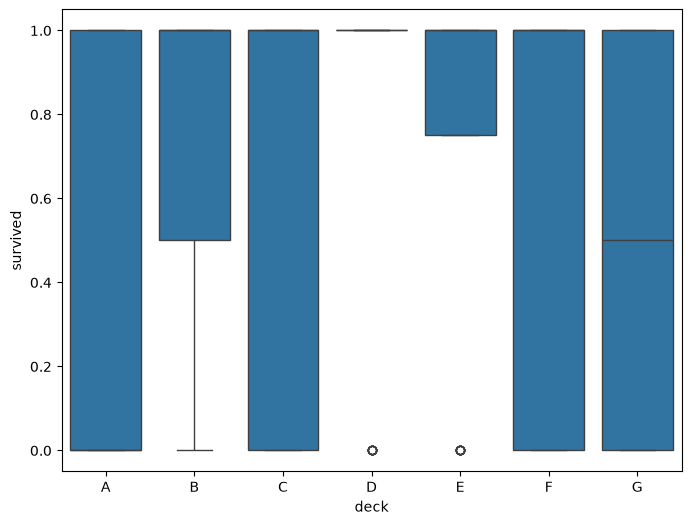

In [38]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x= 'deck',y='survived')

In [ ]:
# from scipy.stats import chi2_contingency

# # Create a contingency table
# contingency_table = pd.crosstab(df['deck'], df['survived'])

# # Run the test
# chi2, p_val, dof, expected = chi2_contingency(contingency_table)
# print(f"P-value: {p_val}")

from scipy.stats import chi2_contingency

categorical_cols = ['deck', 'sex', 'pclass', 'embarked', 'alone', 'class', 'who', 'sibsp', 'parch', 'embark_town']
target_col = 'survived'

chi2_results = []

for col in categorical_cols:
    # Crosstab (contingency table)
    contingency_table = pd.crosstab(df[col], df[target_col])
    
    # Chi-square test
    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    
    # Results
    chi2_results.append({
        'Feature': col,
        'Chi2 Statistic': round(chi2, 4),
        'P-value': p_val,
        # If p-value is less then 0.05 relationship is strong
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

# 4. Results ko ek pyari si DataFrame table mein convert krien
results_df = pd.DataFrame(chi2_results)

# 5. Table ko P-value ke mutabiq sort krien (sab se important columns upar aayenge)
results_df = results_df.sort_values(by='P-value')
print(results_df)



       Feature  Chi2 Statistic       P-value Significant
6          who        226.4956  6.563012e-50         Yes
1          sex        206.3995  8.383409e-47         Yes
5        class         89.0001  4.719180e-20         Yes
2       pclass         89.0001  4.719180e-20         Yes
4        alone         23.7307  1.108032e-06         Yes
3     embarked         23.3640  8.444574e-06         Yes
9  embark_town         23.3640  8.444574e-06         Yes
7        sibsp         24.4761  4.267397e-04         Yes
8        parch         22.7769  8.747518e-04         Yes
0         deck          8.1180  2.295854e-01          No


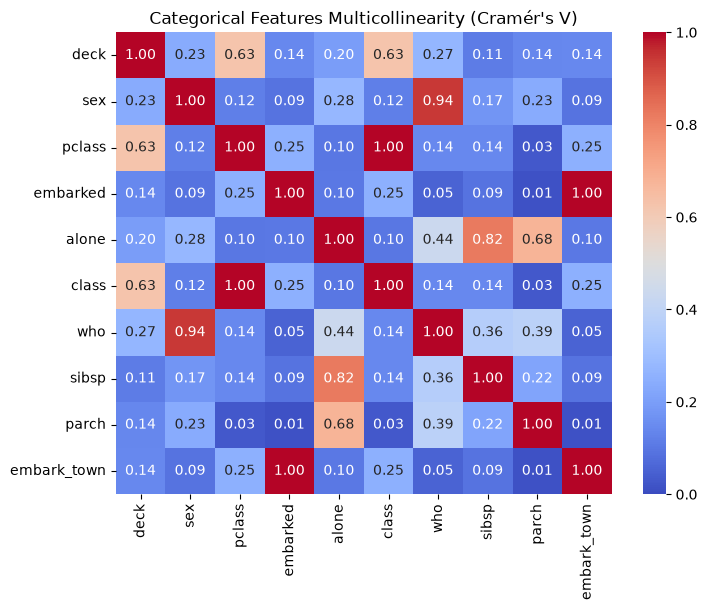

In [46]:
# 2. Cramér's V calculate karne ka function
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 3. Khali Matrix (DataFrame) banana columns ke size ka
n_cols = len(categorical_cols)
matrix = np.zeros((n_cols, n_cols))

# 4. Har column ka doosre column ke saath score nikalna
for i in range(n_cols):
    for j in range(n_cols):
        matrix[i, j] = cramers_v(df[categorical_cols[i]], df[categorical_cols[j]])

# Matrix ko DataFrame mein convert krien
cramers_v_matrix = pd.DataFrame(matrix, index=categorical_cols, columns=categorical_cols)

# 5. Multicollinearity dekhne ke liye Heatmap plot krien
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_v_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title("Categorical Features Multicollinearity (Cramér's V)")
plt.show()

# Data Cleaning and Preprocessing

In [40]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [41]:
df.shape

(891, 15)

In [42]:
df.duplicated().sum()

np.int64(107)

In [43]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [44]:
df.shape

(784, 15)

In [ ]:
# Dropping Columns

columns_to_drop = ['deck','who','embarked',]
df.drop(columns=columns_to_drop, inplace=True)